In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [34]:
df = pd.read_csv("winequality-red.csv", sep=';')

In [36]:
df.head()

,"fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality"
0,"7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0...."
1,"7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.2,0...."
2,"7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0..."
3,"11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,..."
4,"7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0...."


In [37]:
df.shape

(1599, 1)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 1 columns):
 #   Column                                                                                                                                             Non-Null Count  Dtype 
---  ------                                                                                                                                             --------------  ----- 
 0   fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality  1599 non-null   object
dtypes: object(1)
memory usage: 12.6+ KB


In [39]:
df.isnull().sum()

fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality    0
dtype: int64

In [40]:
df.describe()

,"fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality"
count,1599
unique,1359
top,"7.5,0.51,0.02,1.7,0.084,13.0,31.0,0.9953799999..."
freq,4


In [42]:
print(df.columns)

Index(['fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality'], dtype='object')


In [43]:
import pandas as pd

df = pd.read_csv("winequality-red.csv")

In [44]:
print(df.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [45]:
print(df['quality'].value_counts())

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


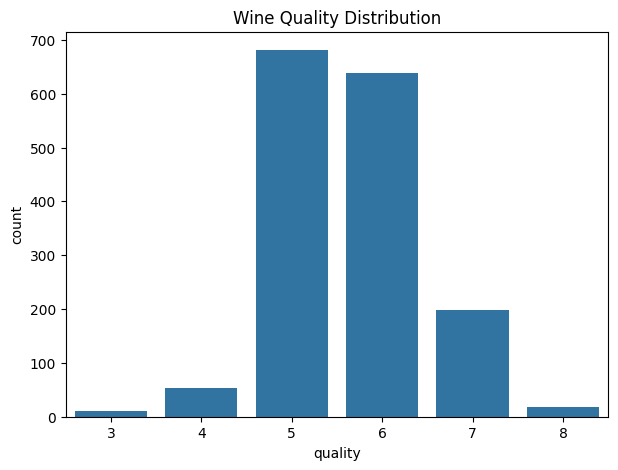

In [46]:
plt.figure(figsize=(7,5))
sns.countplot(x='quality', data=df)
plt.title("Wine Quality Distribution")
plt.show()

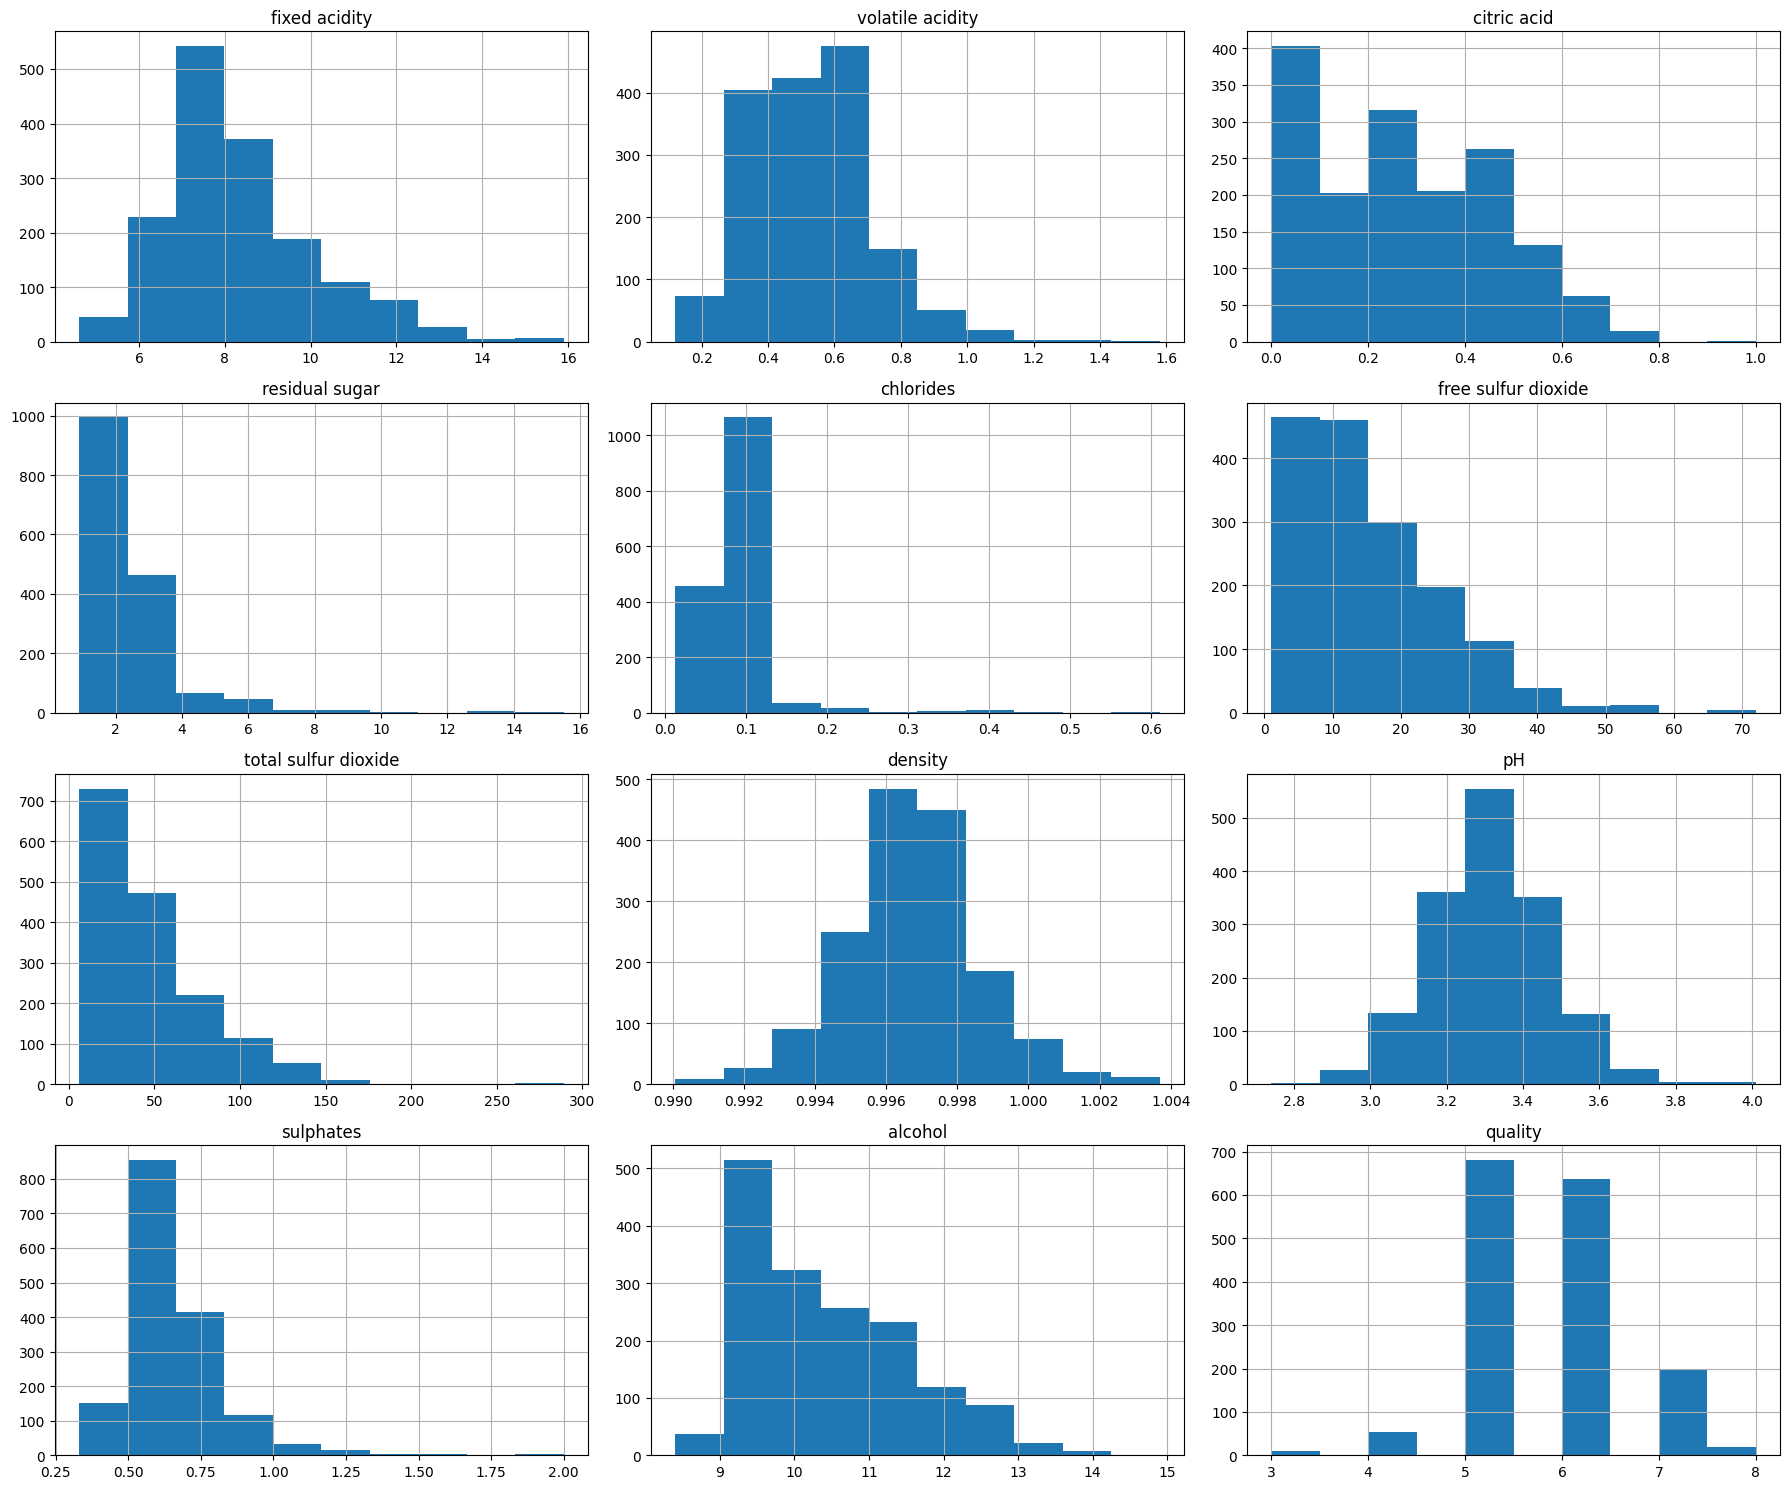

In [47]:
df.hist(figsize=(18,15))
plt.tight_layout()
plt.show()

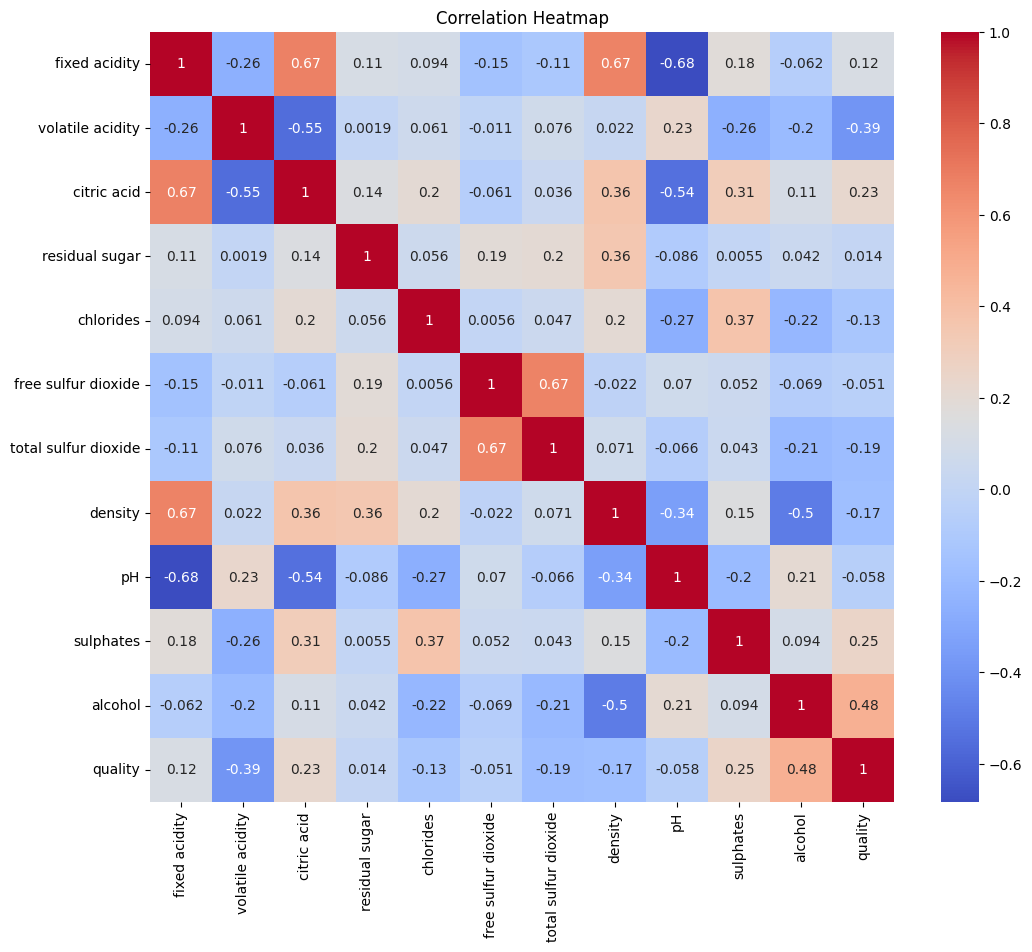

In [48]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [49]:
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [50]:
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

In [51]:
df['quality'].value_counts()

quality
0    1382
1     217
Name: count, dtype: int64

In [52]:
X = df.drop('quality', axis=1)
y = df['quality']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [56]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.9375
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       277
           1       0.93      0.58      0.71        43

    accuracy                           0.94       320
   macro avg       0.93      0.79      0.84       320
weighted avg       0.94      0.94      0.93       320



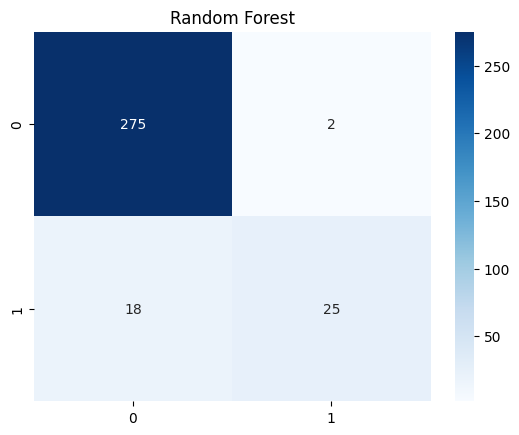

In [57]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest")
plt.show()

In [58]:
sgd = SGDClassifier(random_state=42)

sgd.fit(X_train, y_train)

sgd_pred = sgd.predict(X_test)

In [59]:
print("Accuracy:", accuracy_score(y_test, sgd_pred))
print(classification_report(y_test, sgd_pred))

Accuracy: 0.86875
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       277
           1       0.51      0.47      0.49        43

    accuracy                           0.87       320
   macro avg       0.72      0.70      0.71       320
weighted avg       0.86      0.87      0.87       320



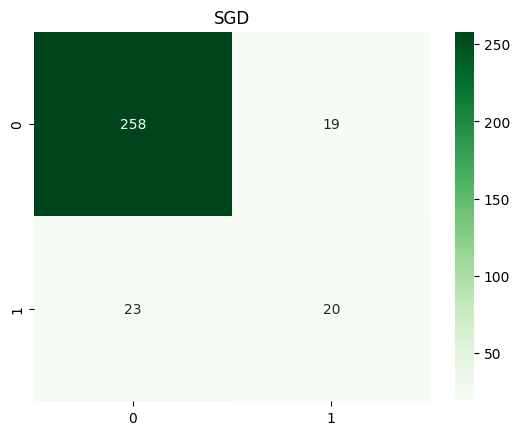

In [60]:
cm = confusion_matrix(y_test, sgd_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("SGD")
plt.show()

In [61]:
svc = SVC(random_state=42)

svc.fit(X_train, y_train)

svc_pred = svc.predict(X_test)

In [62]:
print("Accuracy:", accuracy_score(y_test, svc_pred))
print(classification_report(y_test, svc_pred))

Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       277
           1       0.76      0.37      0.50        43

    accuracy                           0.90       320
   macro avg       0.84      0.68      0.72       320
weighted avg       0.89      0.90      0.88       320



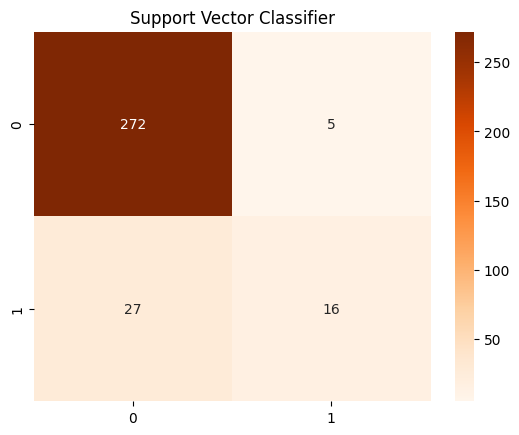

In [63]:
cm = confusion_matrix(y_test, svc_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Support Vector Classifier")
plt.show()

In [64]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

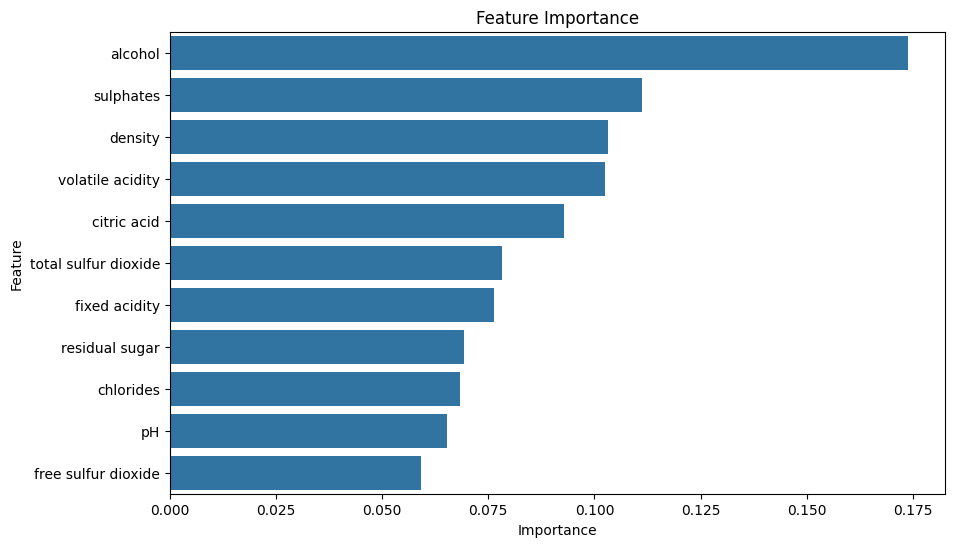

In [65]:
plt.figure(figsize=(10,6))

sns.barplot(data=importance, x='Importance', y='Feature')

plt.title("Feature Importance")

plt.show()

In [66]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SGD', 'SVC'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.93750
1,SGD,0.86875
2,SVC,0.90000


In [67]:
best_model = comparison.loc[comparison['Accuracy'].idxmax()]
print(best_model)

Model       Random Forest
Accuracy           0.9375
Name: 0, dtype: object
